In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import random

In [2]:
data = {
    'idnex': [],
    'numHits': [],
    'r': [],
    'phi': [],
    'qOverPt': []
}

path = '../../../../temp/result_MultipleHelixDetectionTest_Basic.csv'
with open(path, 'r') as file:
    for line in file:
        line = line.split(',')
        line = [x.strip() for x in line]
        data['idnex'].append(int(line[0]))
        data['numHits'].append(int(line[1]))
        data['r'].append(float(line[2]))
        data['phi'].append(float(line[3]))
        data['qOverPt'].append(float(line[4]))

for i in range(0, len(data['idnex'])):
    print(data['idnex'][i], data['numHits'][i], data['r'][i], data['phi'][i], data['qOverPt'][i])

0 6 1176.34 2.09811 0.000425049
1 7 1177.69 2.09811 0.000424561
2 7 1179.04 2.09811 0.000424072
3 7 1180.4 2.09811 0.000423584
4 7 1184.5 2.09941 0.000422119
5 7 1169.62 2.09681 0.00042749
6 7 1170.95 2.09681 0.000427002
7 7 1172.3 2.09681 0.000426514
8 6 1173.64 2.09681 0.000426025
9 6 1174.99 2.09681 0.000425537
10 8 1185.87 2.09941 0.000421631
11 7 1187.25 2.09941 0.000421143
12 7 1188.62 2.09941 0.000420654
13 7 1190.01 2.09941 0.000420166
14 6 1191.39 2.09941 0.000419678
15 6 1192.78 2.09941 0.000419189
16 6 1162.98 1.99544 0.000429932
17 6 1166.95 1.99673 0.000428467
18 6 1169.62 1.99673 0.00042749
19 6 1170.95 1.99673 0.000427002
20 6 1172.3 1.99673 0.000426514
21 6 1176.34 1.99803 0.000425049
22 6 1177.69 1.99803 0.000424561
23 6 1184.5 1.99933 0.000422119
24 6 1185.87 1.99933 0.000421631
25 6 1187.25 1.99933 0.000421143
26 6 1231.51 1.99673 0.000406006
27 6 1926.62 2.09811 0.000259521
28 6 1930.25 2.09811 0.000259033
29 6 1948.62 2.09811 0.000256592
30 6 1952.34 2.09811 0.0002

In [3]:
b_magnitude = 2
min_q_over_pt = min(data['qOverPt'])
max_q_over_pt = max(data['qOverPt'])
min_phi = min(data['phi'])
max_phi = max(data['phi'])
min_r = min(data['r'])
max_r = max(data['r'])
print(min_q_over_pt, max_q_over_pt, min_phi, max_phi, min_r, max_r)

2.22168e-05 0.000429932 1.89796 2.20078 1162.98 22505.5


In [4]:
q_over_pt_division_level = 10
phi_division_level = 10
q_over_pt_min = 0
q_over_pt_max = 0.0005
q_over_pt_step = (q_over_pt_max - q_over_pt_min) / 2**q_over_pt_division_level
phi_min = 0.343612 - 0.42 + 0.5 * math.pi
phi_max = 0.834486 + 0.42 + 0.5 * math.pi
phi_step = (phi_max - phi_min) / 2**phi_division_level
r_min = 0
r_max = 25000
r_step = (r_max - r_min) / 2**q_over_pt_division_level

print(q_over_pt_min, q_over_pt_max, phi_min, phi_max, r_min, r_max)

0 0.0005 1.4944083267948964 2.8252823267948965 0 25000


In [5]:
q_over_pts_grid = [(q_over_pt_min + q_over_pt_step * i, q_over_pt_min + q_over_pt_step * (i + 1)) for i in range(2**q_over_pt_division_level)]
phi_grid = [(phi_min + phi_step * i, phi_min + phi_step * (i + 1)) for i in range(2**phi_division_level)]
rs_grid = [(r_min + r_step * i, r_min + r_step * (i + 1)) for i in range(2**8)]

q_over_pt_heat_map = np.zeros((2**q_over_pt_division_level, 2**phi_division_level))
r_heat_map = np.zeros((2**q_over_pt_division_level, 2**phi_division_level))
for index in data['idnex']:
    q_over_pt = data['qOverPt'][index]
    phi = data['phi'][index]
    r = data['r'][index]
    num_hits = data['numHits'][index]
    q_over_pt_index = int((q_over_pt - q_over_pt_min) / q_over_pt_step)
    phi_index = int((phi - phi_min) / phi_step)
    r_index = int((r - r_min) / r_step)
    q_over_pt_heat_map[q_over_pt_index][phi_index] = num_hits
    r_heat_map[r_index][phi_index] = num_hits
    print(q_over_pt_index, phi_index, r_index)

870 464 48
869 464 48
868 464 48
867 464 48
864 465 48
875 463 47
874 463 47
873 463 48
872 463 48
871 463 48
863 465 48
862 465 48
861 465 48
860 465 48
859 465 48
858 465 48
880 385 47
877 386 47
875 386 47
874 386 47
873 386 48
870 387 48
869 387 48
864 388 48
863 388 48
862 388 48
831 386 50
531 464 78
530 464 79
525 464 79
524 464 79
523 464 80
522 464 80
521 464 80
520 464 80
519 465 80
519 464 80
518 465 80
518 464 80
517 465 81
516 465 81
515 465 81
514 465 81
525 463 79
534 387 78
533 387 78
532 387 78
531 387 78
530 387 79
531 384 78
529 387 79
528 387 79
528 385 79
527 387 79
527 385 79
525 387 79
525 386 79
524 387 79
524 386 79
523 387 80
523 386 80
522 387 80
522 386 80
521 387 80
520 387 80
519 388 80
518 388 80
517 388 81
516 388 81
519 387 80
518 387 80
515 388 81
514 389 81
514 388 81
513 389 81
513 388 81
512 389 81
522 310 80
521 310 80
520 310 80
513 312 81
512 312 81
519 311 80
519 310 80
518 311 80
517 311 81
516 311 81
515 311 81
514 311 81
513 311 81
54 542 769

In [6]:
print(r_heat_map[42][388])

0.0


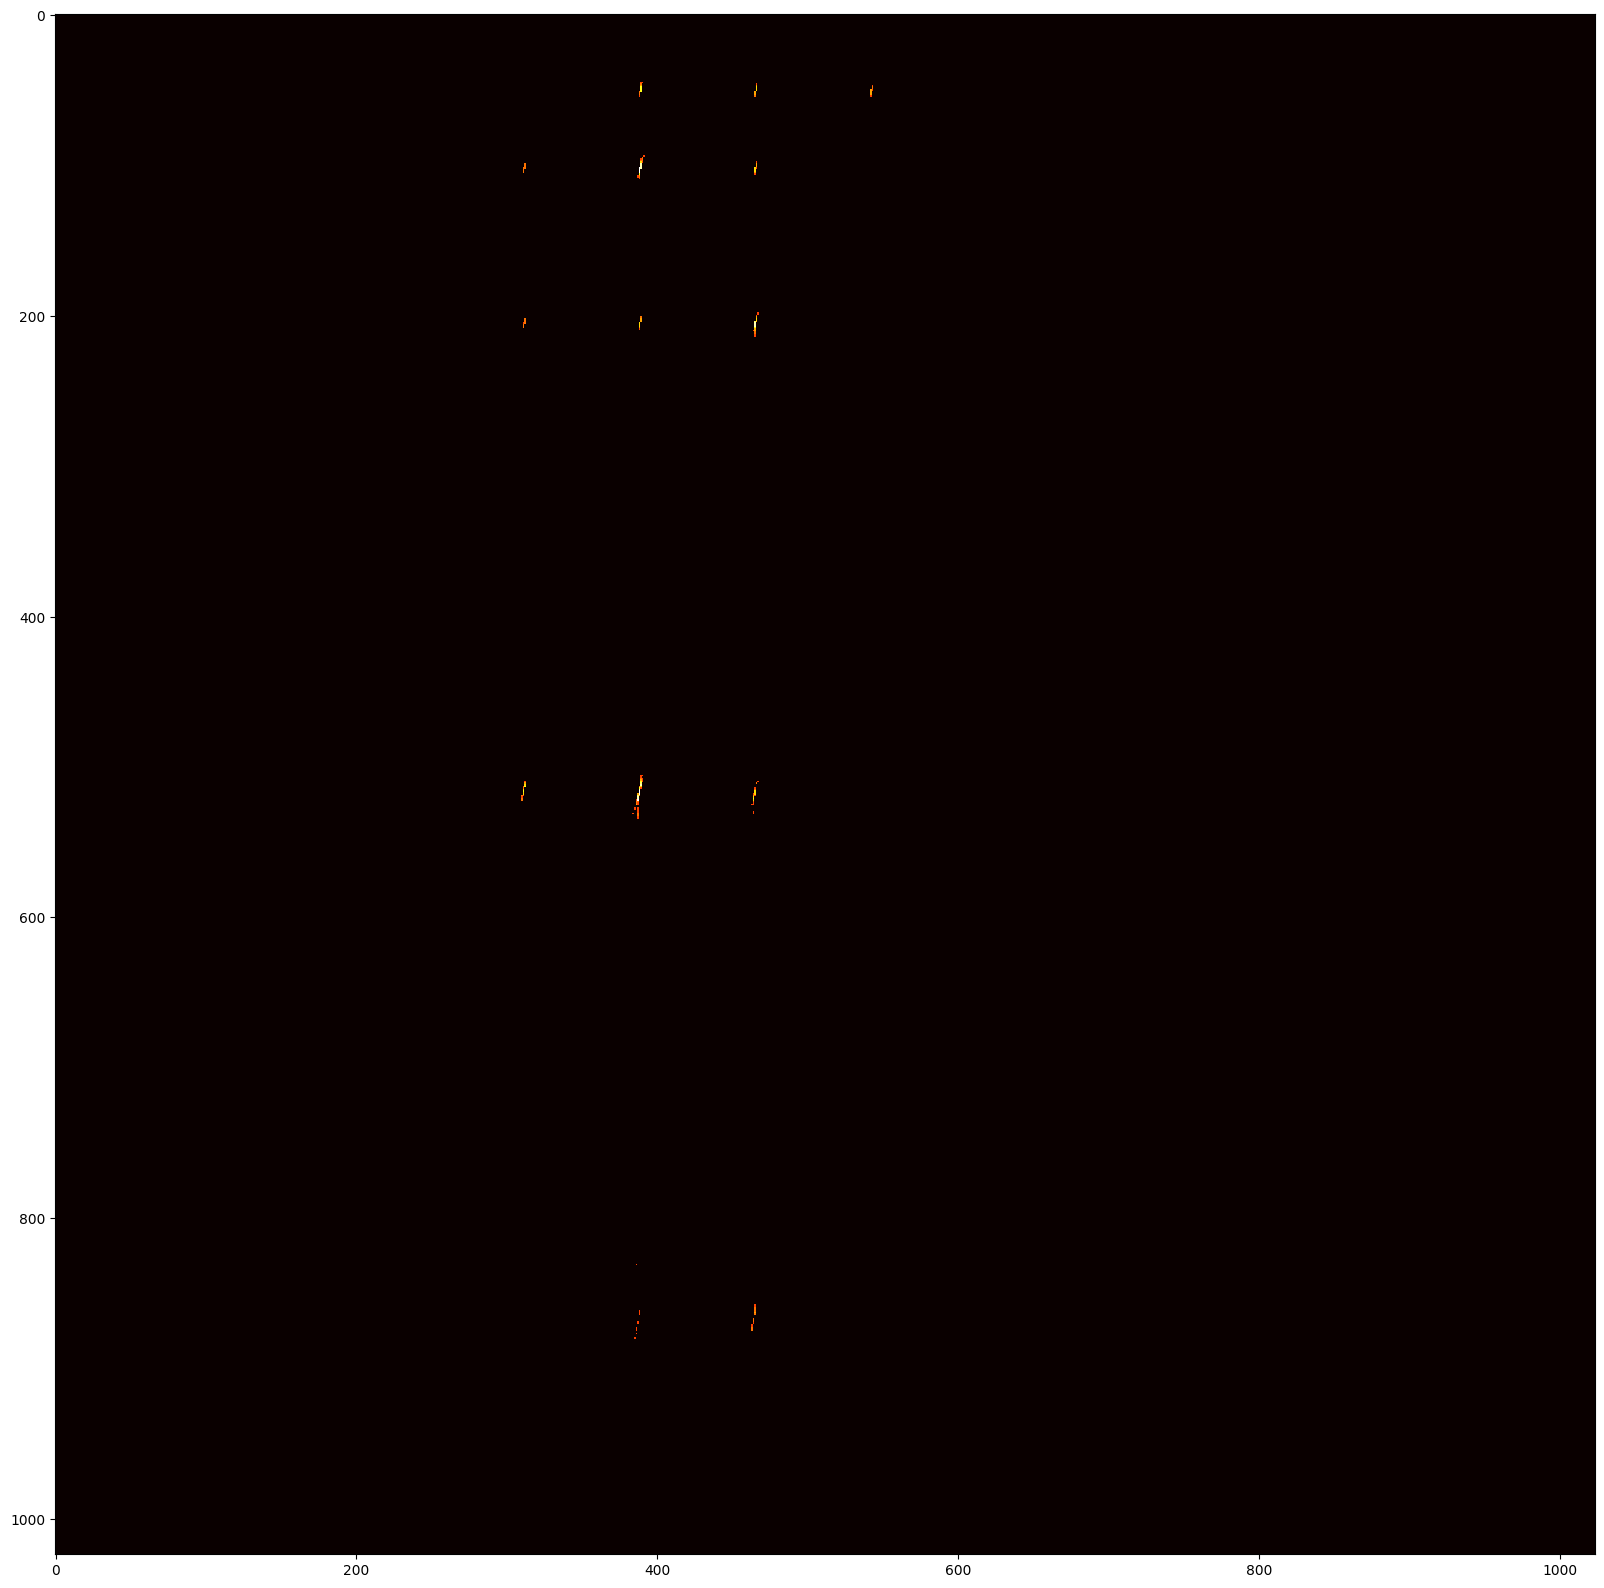

In [7]:
figure = plt.gcf()
figure.set_size_inches(20, 20)
plt.imshow(q_over_pt_heat_map, cmap='hot', interpolation='nearest')

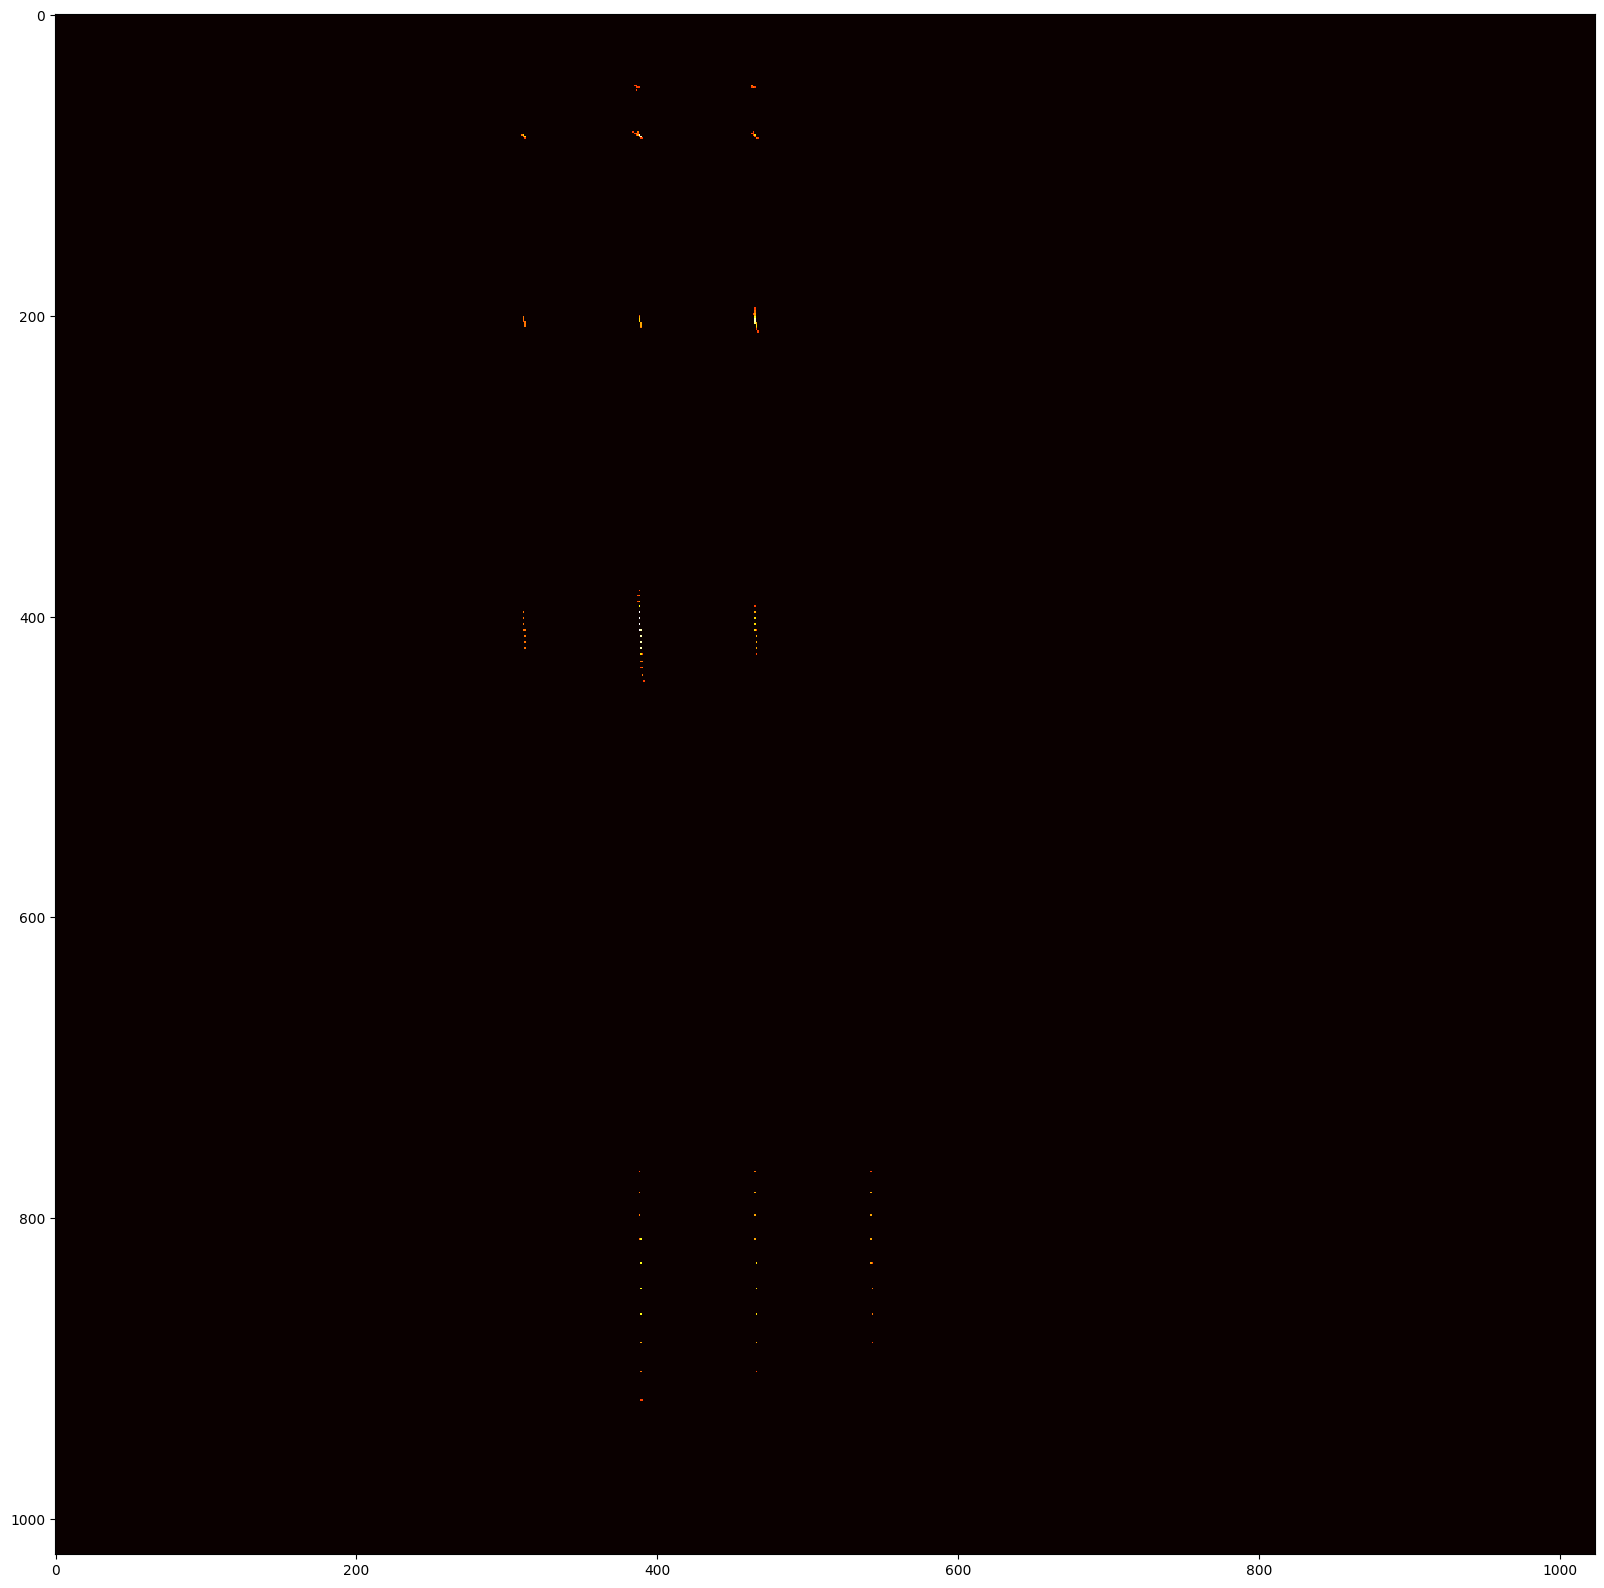

In [8]:
figure = plt.gcf()
figure.set_size_inches(20, 20)
plt.imshow(r_heat_map, cmap='hot', interpolation='nearest')

In [9]:
class DetectorProperties:
    max_abs_xy = 1100
    max_abs_z = 3100

In [10]:
def get_3d_plot_figure(figure_size, keep_aspect_ratio=False):
    figure = plt.figure(figsize=figure_size)
    ax = plt.axes(projection='3d')
    ax.set_xlim([-DetectorProperties.max_abs_z, DetectorProperties.max_abs_z] if keep_aspect_ratio else [-DetectorProperties.max_abs_xy, DetectorProperties.max_abs_xy])
    ax.set_ylim([-DetectorProperties.max_abs_z, DetectorProperties.max_abs_z])
    ax.set_zlim([-DetectorProperties.max_abs_z, DetectorProperties.max_abs_z] if keep_aspect_ratio else [-DetectorProperties.max_abs_xy, DetectorProperties.max_abs_xy])
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_zlabel('y')
    ax.set_facecolor('black')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.zaxis.label.set_color('white')
    return figure, ax

In [11]:
def plot_points(points, sample_size=None, figure=None, ax=None, keep_aspect_ratio=False, figure_size=(10, 10), point_size=4, color='red'):
    if figure is None or ax is None:
        figure, ax = get_3d_plot_figure(figure_size=figure_size, keep_aspect_ratio=keep_aspect_ratio)

    points_to_plot = random.sample(points, sample_size) if sample_size is not None else points
    points_x = [point['x'] for point in points_to_plot]
    points_y = [point['y'] for point in points_to_plot]
    points_z = [point['z'] for point in points_to_plot]
    ax.scatter3D(points_x, points_z, points_y, color=color, s=point_size)

In [12]:
class Wedge:
    def __init__(self, z_angle_min, z_angle_max, x_angle_min, x_angle_max, interaction_region_width):
        self.z_angle_min = z_angle_min
        self.z_angle_max = z_angle_max
        self.x_angle_min = x_angle_min
        self.x_angle_max = x_angle_max
        self.interaction_region_width = interaction_region_width

    def get_outermost_points(self):
        def angles_to_xyz(z_angle, x_angle):
            x_plane_direction_z = math.cos(x_angle)
            x_plane_direction_y = math.sin(x_angle)

            x_plane_scale_to_z_limit = abs(x_plane_direction_z) / DetectorProperties.max_abs_z
            x_plane_scale_to_y_limit = abs(x_plane_direction_y) / DetectorProperties.max_abs_xy
            scale = 1 / max(x_plane_scale_to_z_limit, x_plane_scale_to_y_limit)
            
            return {
                'x': x_plane_direction_y * math.cos(z_angle) * scale,
                'y': x_plane_direction_y * math.sin(z_angle) * scale,
                'z': x_plane_direction_z * scale
            }

        return {
            'z_angle_min_x_angle_min': angles_to_xyz(self.z_angle_min, self.x_angle_min),
            'z_angle_min_x_angle_max': angles_to_xyz(self.z_angle_min, self.x_angle_max),
            'z_angle_max_x_angle_min': angles_to_xyz(self.z_angle_max, self.x_angle_min),
            'z_angle_max_x_angle_max': angles_to_xyz(self.z_angle_max, self.x_angle_max)
        }
    
    def get_interaction_region_zs(self):
        return {
            'x_angle_min': (1 if self.x_angle_min <= math.pi else -1) * self.interaction_region_width / 2,
            'x_angle_max': (-1 if self.x_angle_max <= math.pi else 1) * self.interaction_region_width / 2,
        }

def plot_wedge_lines(figure, ax, wedge, color='yellow'):
    outermost_points = wedge.get_outermost_points()
    interaction_region_zs = wedge.get_interaction_region_zs()

    xs = []
    xs.append([0, outermost_points['z_angle_min_x_angle_min']['x']])
    xs.append([0, outermost_points['z_angle_min_x_angle_max']['x']])
    xs.append([0, outermost_points['z_angle_max_x_angle_min']['x']])
    xs.append([0, outermost_points['z_angle_max_x_angle_max']['x']])
    xs.append([outermost_points['z_angle_min_x_angle_min']['x'], outermost_points['z_angle_min_x_angle_max']['x']])
    xs.append([outermost_points['z_angle_max_x_angle_min']['x'], outermost_points['z_angle_max_x_angle_max']['x']])
    xs.append([outermost_points['z_angle_min_x_angle_min']['x'], outermost_points['z_angle_max_x_angle_min']['x']])
    xs.append([outermost_points['z_angle_min_x_angle_max']['x'], outermost_points['z_angle_max_x_angle_max']['x']])

    ys = []
    ys.append([0, outermost_points['z_angle_min_x_angle_min']['y']])
    ys.append([0, outermost_points['z_angle_min_x_angle_max']['y']])
    ys.append([0, outermost_points['z_angle_max_x_angle_min']['y']])
    ys.append([0, outermost_points['z_angle_max_x_angle_max']['y']])
    ys.append([outermost_points['z_angle_min_x_angle_min']['y'], outermost_points['z_angle_min_x_angle_max']['y']])
    ys.append([outermost_points['z_angle_max_x_angle_min']['y'], outermost_points['z_angle_max_x_angle_max']['y']])
    ys.append([outermost_points['z_angle_min_x_angle_min']['y'], outermost_points['z_angle_max_x_angle_min']['y']])
    ys.append([outermost_points['z_angle_min_x_angle_max']['y'], outermost_points['z_angle_max_x_angle_max']['y']])

    zs = []
    zs.append([interaction_region_zs['x_angle_min'], outermost_points['z_angle_min_x_angle_min']['z']])
    zs.append([interaction_region_zs['x_angle_max'], outermost_points['z_angle_min_x_angle_max']['z']])
    zs.append([interaction_region_zs['x_angle_min'], outermost_points['z_angle_max_x_angle_min']['z']])
    zs.append([interaction_region_zs['x_angle_max'], outermost_points['z_angle_max_x_angle_max']['z']])
    zs.append([outermost_points['z_angle_min_x_angle_min']['z'], outermost_points['z_angle_min_x_angle_max']['z']])
    zs.append([outermost_points['z_angle_max_x_angle_min']['z'], outermost_points['z_angle_max_x_angle_max']['z']])
    zs.append([outermost_points['z_angle_min_x_angle_min']['z'], outermost_points['z_angle_max_x_angle_min']['z']])
    zs.append([outermost_points['z_angle_min_x_angle_max']['z'], outermost_points['z_angle_max_x_angle_max']['z']])

    for i in range(len(xs)):
        ax.plot(xs[i], zs[i], ys[i], color=color)

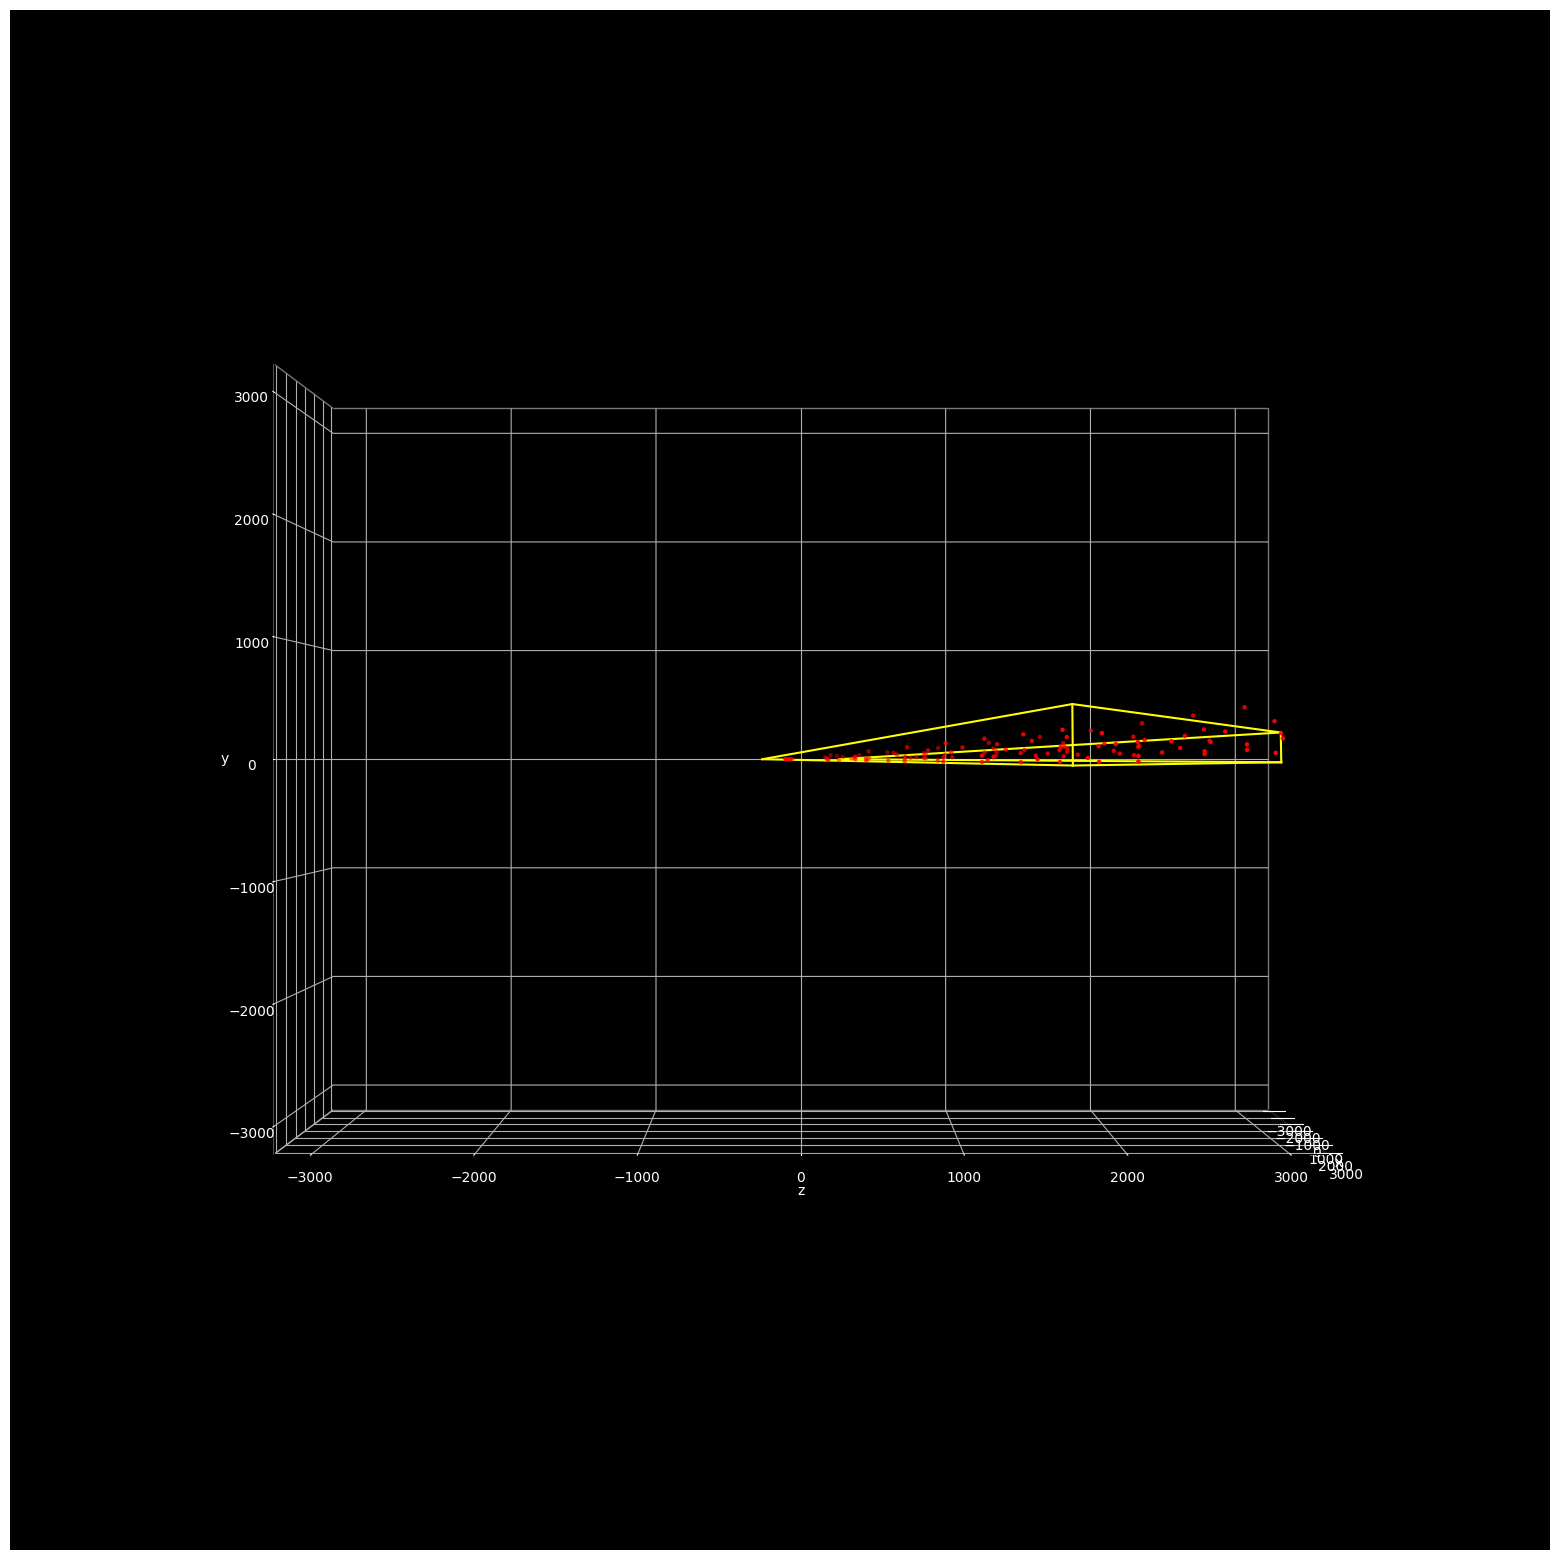

In [47]:
points_str = """
2025-02-18 20:22:54.999105	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.97756, -0.665771, -99.5004),
2025-02-18 20:22:54.999186	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(127.589, -2.24585, 355.359),
2025-02-18 20:22:54.999198	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(244.791, 7.69592, 810.218),
2025-02-18 20:22:54.999209	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(360.456, 29.064, 1265.08),
2025-02-18 20:22:54.999219	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(473.473, 61.6532, 1719.94),
2025-02-18 20:22:54.999229	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(582.757, 105.15, 2174.79),
2025-02-18 20:22:54.999239	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(687.258, 159.137, 2629.65),
2025-02-18 20:22:54.999249	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(785.971, 223.096, 3084.51),
2025-02-18 20:22:54.999259	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.72868, 2.31262, -92.1061),
2025-02-18 20:22:54.999269	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(97.7725, 27.2178, 235.382),
2025-02-18 20:22:54.999279	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(183.663, 58.7588, 562.871),
2025-02-18 20:22:54.999289	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(266.9, 96.7526, 890.359),
2025-02-18 20:22:54.999299	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(347.001, 140.978, 1217.85),
2025-02-18 20:22:54.999309	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(423.499, 191.178, 1545.34),
2025-02-18 20:22:54.999326	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(495.949, 247.061, 1872.82),
2025-02-18 20:22:54.999349	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(563.932, 308.301, 2200.31),
2025-02-18 20:22:54.999368	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(627.05, 374.543, 2527.8),
2025-02-18 20:22:54.999393	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(684.938, 445.402, 2855.29),
2025-02-18 20:22:54.999418	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.97659, -0.682373, -69.6707),
2025-02-18 20:22:54.999444	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(111.804, -4.78992, 178.047),
2025-02-18 20:22:54.999463	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(213.709, -3.7052, 425.765),
2025-02-18 20:22:54.999479	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(315.427, 2.56921, 673.483),
2025-02-18 20:22:54.999504	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(416.692, 14.0167, 921.201),
2025-02-18 20:22:54.999515	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(517.244, 30.6077, 1168.92),
2025-02-18 20:22:54.999525	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(616.819, 52.2991, 1416.64),
2025-02-18 20:22:54.999535	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(715.16, 79.0347, 1664.35),
2025-02-18 20:22:54.999546	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(812.012, 110.745, 1912.07),
2025-02-18 20:22:54.999561	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(907.122, 147.347, 2159.79),
2025-02-18 20:22:54.999587	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.99488, 0.317017, -87.7583),
2025-02-18 20:22:54.999608	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(93.253, 4.90515, 167.538),
2025-02-18 20:22:54.999631	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(176.248, 12.9596, 422.835),
2025-02-18 20:22:54.999651	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(258.834, 24.4667, 678.132),
2025-02-18 20:22:54.999669	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(340.869, 39.4062, 933.429),
2025-02-18 20:22:54.999693	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(422.211, 57.7523, 1188.73),
2025-02-18 20:22:54.999720	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(502.716, 79.4729, 1444.02),
2025-02-18 20:22:54.999744	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(582.247, 104.53, 1699.32),
2025-02-18 20:22:54.999764	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(660.664, 132.881, 1954.62),
2025-02-18 20:22:54.999787	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(737.83, 164.476, 2209.91),
2025-02-18 20:22:54.999811	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(813.613, 199.26, 2465.21),
2025-02-18 20:22:54.999837	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(887.88, 237.172, 2720.51),
2025-02-18 20:22:54.999857	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.91329, 1.31323, -98.0067),
2025-02-18 20:22:54.999881	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(139.11, 23.0872, 350.024),
2025-02-18 20:22:54.999902	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(266.604, 53.2734, 798.054),
2025-02-18 20:22:54.999929	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(391.848, 91.7426, 1246.08),
2025-02-18 20:22:54.999954	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(514.304, 138.329, 1694.12),
2025-02-18 20:22:54.999978	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(633.448, 192.834, 2142.15),
2025-02-18 20:22:54.999997	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(748.767, 255.022, 2590.18),
2025-02-18 20:22:55.000023	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(859.767, 324.628, 3038.21),
2025-02-18 20:22:55.000046	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.97563, -0.697266, -69.6707),
2025-02-18 20:22:55.000070	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(149.33, -8.34717, 248.824),
2025-02-18 20:22:55.000093	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(288.843, -12.1045, 567.318),
2025-02-18 20:22:55.000119	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(428.406, -11.9668, 885.813),
2025-02-18 20:22:55.000140	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(567.912, -7.93359, 1204.31),
2025-02-18 20:22:55.000166	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(707.25, -0.00878906, 1522.8),
2025-02-18 20:22:55.000187	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(846.313, 11.8022, 1841.3),
2025-02-18 20:22:55.000213	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(984.993, 27.4897, 2159.79),
2025-02-18 20:22:55.000235	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.99543, 0.302246, -92.1061),
2025-02-18 20:22:55.000262	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(149.417, 6.60254, 328.95),
2025-02-18 20:22:55.000285	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(288.608, 16.792, 750.007),
2025-02-18 20:22:55.000306	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(427.461, 30.8623, 1171.06),
2025-02-18 20:22:55.000328	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(565.867, 48.8027, 1592.12),
2025-02-18 20:22:55.000356	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(703.718, 70.5986, 2013.18),
2025-02-18 20:22:55.000380	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(840.907, 96.2334, 2434.23),
2025-02-18 20:22:55.000408	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(977.327, 125.688, 2855.29),
2025-02-18 20:22:55.000428	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.91535, 1.29883, -62.161),
2025-02-18 20:22:55.000447	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(117.373, 16.667, 158.856),
2025-02-18 20:22:55.000466	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(224.471, 34.3652, 379.873),
2025-02-18 20:22:55.000485	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(331.16, 54.3843, 600.89),
2025-02-18 20:22:55.000507	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(437.39, 76.7144, 821.906),
2025-02-18 20:22:55.000536	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(543.109, 101.345, 1042.92),
2025-02-18 20:22:55.000561	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(648.269, 128.266, 1263.94),
2025-02-18 20:22:55.000583	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(752.82, 157.462, 1484.96),
2025-02-18 20:22:55.000612	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(856.712, 188.922, 1705.97),
2025-02-18 20:22:55.000635	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(959.897, 222.629, 1926.99),
2025-02-18 20:22:55.000656	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.97531, -0.702148, -69.6707),
2025-02-18 20:22:55.000679	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(119.38, -7.74805, 178.047),
2025-02-18 20:22:55.000706	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(228.855, -13.5947, 425.765),
2025-02-18 20:22:55.000732	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(338.388, -18.2402, 673.483),
2025-02-18 20:22:55.000756	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(447.965, -21.6846, 921.201),
2025-02-18 20:22:55.000779	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(557.573, -23.9277, 1168.92),
2025-02-18 20:22:55.000803	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(667.2, -24.9688, 1416.64),
2025-02-18 20:22:55.000828	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(776.831, -24.8096, 1664.35),
2025-02-18 20:22:55.000853	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(886.454, -23.4463, 1912.07),
2025-02-18 20:22:55.000877	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(996.055, -20.8818, 2159.79),
2025-02-18 20:22:55.000904	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.99558, 0.296875, -92.1061),
2025-02-18 20:22:55.000928	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(99.6401, 3.4082, 175.839),
2025-02-18 20:22:55.000949	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(189.253, 7.32324, 443.784),
2025-02-18 20:22:55.000978	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(278.827, 12.041, 711.729),
2025-02-18 20:22:55.000999	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(368.356, 17.5635, 979.674),
2025-02-18 20:22:55.001025	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(457.831, 23.8877, 1247.62),
2025-02-18 20:22:55.001048	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(547.246, 31.0146, 1515.56),
2025-02-18 20:22:55.001074	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(636.593, 38.9434, 1783.51),
2025-02-18 20:22:55.001096	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(725.866, 47.6729, 2051.45),
2025-02-18 20:22:55.001120	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(815.057, 57.2031, 2319.4),
2025-02-18 20:22:55.001139	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(904.158, 67.5332, 2587.34),
2025-02-18 20:22:55.001164	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(993.164, 78.6611, 2855.29),
2025-02-18 20:22:55.001189	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.91603, 1.29297, -99.5004),
2025-02-18 20:22:55.001215	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(149.545, 20.5791, 355.359),
2025-02-18 20:22:55.001241	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(288.887, 41.8301, 810.218),
2025-02-18 20:22:55.001269	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(427.917, 65.0439, 1265.08),
2025-02-18 20:22:55.001297	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(566.605, 90.2158, 1719.94),
2025-02-18 20:22:55.001322	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(704.925, 117.339, 2174.79),
2025-02-18 20:22:55.001351	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(842.849, 146.408, 2629.65),
2025-02-18 20:22:55.001380	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(980.349, 177.42, 3084.51),
2025-02-18 20:22:55.001407	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.99567, 0.294922, -98.0067),
2025-02-18 20:22:55.001432	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(151.227, 4.99023, 350.024),
2025-02-18 20:22:55.001461	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(292.422, 10.6855, 798.054),
2025-02-18 20:22:55.001489	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(433.573, 17.375, 1246.08),
2025-02-18 20:22:55.001513	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(574.673, 25.0625, 1694.12),
2025-02-18 20:22:55.001536	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(715.715, 33.7461, 2142.15),
2025-02-18 20:22:55.001560	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(856.692, 43.4277, 2590.18),
2025-02-18 20:22:55.001587	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(997.598, 54.1055, 3038.21),
2025-02-18 20:22:55.001613	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.9164, 1.29102, -76.4842),
2025-02-18 20:22:55.001640	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(149.973, 20.0645, 273.158),
2025-02-18 20:22:55.001665	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(289.894, 39.8242, 622.8),
2025-02-18 20:22:55.001691	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(429.672, 60.5723, 972.442),
2025-02-18 20:22:55.001719	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(569.3, 82.3086, 1322.08),
2025-02-18 20:22:55.001743	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(708.77, 105.029, 1671.73),
2025-02-18 20:22:55.001771	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(848.077, 128.738, 2021.37),
2025-02-18 20:22:55.001798	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(987.213, 153.428, 2371.01),
2025-02-18 20:22:55.001824	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(9.73799, 2.27344, -54.0302),
2025-02-18 20:22:55.001850	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(147.221, 34.9336, 192.965),
2025-02-18 20:22:55.001878	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(284.47, 68.5664, 439.96),
2025-02-18 20:22:55.001903	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(421.478, 103.166, 686.956),
2025-02-18 20:22:55.001931	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(558.238, 138.732, 933.951),
2025-02-18 20:22:55.001957	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(694.744, 175.264, 1180.95),
2025-02-18 20:22:55.001978	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(830.988, 212.762, 1427.94),
2025-02-18 20:22:55.002004	/helix/repo/application/experimental/HelixSolverUsm/test/SingleRegionKernelSuite.cpp:822	createRunAndExtractResult	DEBUG		(966.963, 251.219, 1674.94),
"""

points = []
for line in points_str.split("\n"):
    if line == "":
        continue

    point = tuple(float(i) for i in line[line.find("(") + 1:line.find(")")].split(", "))
    points.append(point)

points = [{
    'x': i[0],
    'y': i[1],
    'z': i[2]
} for i in points]

figure, ax = get_3d_plot_figure(figure_size=(20, 20), keep_aspect_ratio=True)
ax.view_init(elev=0, azim=0, roll=0)
# ax.view_init(elev=0, azim=270, roll=0)
# ax.view_init(elev=90, azim=0, roll=0)
# ax.view_init(elev=135, azim=0, roll=0)

# plot_wedge_lines(figure, ax, Wedge(0.343612, 0.834486, 0.171806, 0.564505, 500), color='yellow')
plot_wedge_lines(figure, ax, Wedge(6.2341, 0.441786, 0.171806, 0.564505, 500), color='yellow')
plot_points(points, figure_size=(20, 20), figure=figure, ax=ax, keep_aspect_ratio=True, point_size=5)